In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from NMS_IOU import NMS, IoU
from ReadData import load_data
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.models import Sequential, load_model


In [2]:
input_shape = (128, 128, 3)
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(256, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(512, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


c:\Users\Inspector 13\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
x, y = load_data()
print(x.shape, y.shape)

(1580, 128, 128, 3) (1580,)


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)   
op = Adam(learning_rate=0.001)
model.compile(optimizer=op, loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))


Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6049 - loss: 1.4503 - val_accuracy: 0.7278 - val_loss: 0.5248
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7179 - loss: 0.5351 - val_accuracy: 0.7384 - val_loss: 0.5159
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7495 - loss: 0.4971 - val_accuracy: 0.7743 - val_loss: 0.4795
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 713ms/step - accuracy: 0.7550 - loss: 0.4906 - val_accuracy: 0.7637 - val_loss: 0.5108
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 826ms/step - accuracy: 0.7667 - loss: 0.4681 - val_accuracy: 0.7722 - val_loss: 0.4729


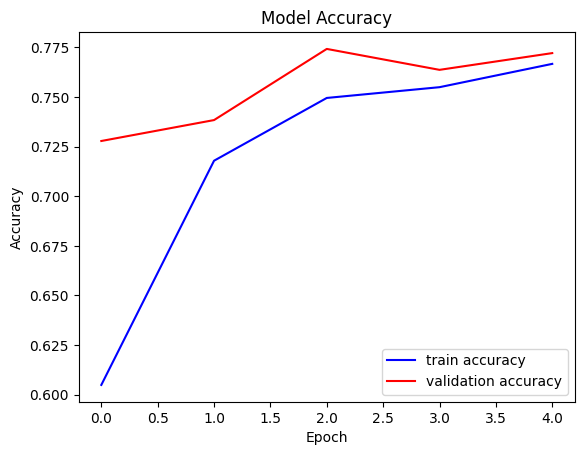

In [30]:
plt.plot(history.history['accuracy'], label='train accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='validation accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'], label='train loss', color='blue')
plt.plot(history.history['val_loss'], label='validation loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [31]:
print(model.evaluate(x_test, y_test))


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.7722 - loss: 0.4729
[0.4728785753250122, 0.7721518874168396]


In [ ]:
# rcnn1 accuracy: 0.7622, loss: 0.4629, validation accuracy: 0.7722, validation loss: 0.4729
# added con2d layer with 512 filters and dense layer with 32 units, reduced learning rate to 0.001, trained for 5 epochs


In [32]:
model.save('rcnn_model1.keras')

In [55]:
def rcnn(image, model):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchQuality()
    rects = ss.process()
    print('Total Number of Region Proposals: {}'.format(len(rects)))
    copy1 = image.copy()
    copy2 = image.copy()
    positive_boxes = []
    probs = []
    for box in rects:
        x1 = box[0]
        y1 = box[1]
        x2 = box[0] + box[2]
        y2 = box[1] + box[3]
        roi = image.copy()[y1:y2, x1:x2]
        roi = cv2.resize(roi, (128, 128))
        roi_use = roi.reshape(1, 128, 128, 3) 
        class_pred = model.predict(roi_use, verbose=0)[0][0] # [[0.7, 0.3]]
        print(class_pred)
        if class_pred > 0.85:
            positive_boxes.append((x1, y1, x2, y2))
            probs.append(class_pred)
            cv2.rectangle(copy1, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cleaned_boxes = NMS(np.array(positive_boxes), 0.1)
    cleaned_boxes = np.asarray(cleaned_boxes, dtype='int')
    for box in cleaned_boxes:
        x1, y1, x2, y2 = box
        cv2.rectangle(copy2, (x1, y1), (x2, y2), (255, 0, 0), 3)
    plt.subplot(1, 2, 1)
    plt.title('Before NMS')
    plt.imshow(copy1)
    plt.subplot(1, 2, 2)
    plt.title('After NMS')
    plt.imshow(copy2)
    plt.show()



Total Number of Region Proposals: 1059
0.34286687
0.44559634
0.44525182
0.15211
0.28807792
0.6686648
0.7124623
0.13078123
0.9161353
0.4089076
0.99894124
0.17348595
0.4720656
0.17655273
0.7612475
0.28721833
0.6758051
0.3920326
0.8128295
0.48808238
0.109732926
0.066691376
0.0060754083
0.8276179
0.0016918529
0.07787121
0.77833414
0.5399205
0.15781583
0.60056305
0.62003285
0.15905075
0.35647944
0.3657048
0.64829075
0.30130827
0.19665527
0.36832452
0.3460843
0.35426912
0.5487151
0.41160798
0.2827094
0.5561821
0.24077071
0.39702752
0.282399
0.0017886799
0.10390868
0.5459801
0.69659126
0.2662168
0.33741614
0.23558566
0.56671196
0.33999604
0.48235515
0.455972
0.16980785
0.41888767
0.3802436
0.0010422103
0.43676546
0.4458951
0.3987872
0.9993209
0.30089986
0.6167978
0.32473156
0.30994937
0.52735436
0.33860534
0.3233449
0.58269405
0.7395573
0.24115627
0.2069941
0.30924258
0.4533659
0.29305017
0.5128072
0.26316854
0.5670142
0.4330594
0.995454
0.9739668
0.12377789
0.26409203
0.62341404
0.4093994
0.

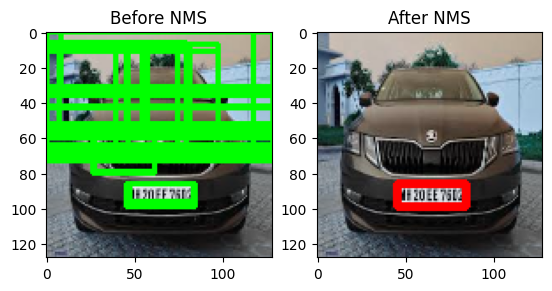

In [56]:
test_img = cv2.imread('test_plate.jpg')
test_img = cv2.resize(test_img, (128, 128))
rcnn_model = load_model('rcnn_model1.keras')
rcnn(test_img, rcnn_model)